# LCDM CMB + BAO + BBN Posterior Plotting

This notebook loads saved artifacts from `mcmc_cmb_bao_bbn_LCDM_driver.ipynb`, reconstructs derived parameters, and reproduces the combined `\sigma_8-\Omega_m` comparison plot.


In [1]:
import os
from pathlib import Path

os.environ.setdefault('XDG_CACHE_HOME', str(Path.cwd() / '.cache'))
os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / '.cache' / 'matplotlib'))
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

import jax
jax.config.update('jax_enable_x64', True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.ndimage import gaussian_filter

from ps_1loop_jax import background as bg

from jaxptpolypol.cmb_mcmc_utils import (
    COMBINATION_COLORS,
    DEFAULT_FIDUCIAL_NATIVE,
    DEFAULT_PLOT_ORDER,
    PAPER_REFERENCE_POINTS,
    artifact_path_for_selector,
    chunked_map,
    get_cache_dir,
    load_available_artifacts,
    native_cosmo_array_from_sampled,
    omega_m_from_native,
    selector_to_label,
    summarize_scalar,
)
from jaxptpolypol.derived import sigma8_from_linear_pk
from jaxptpolypol.model import CosmoEmulator


In [2]:
REPO_ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
for _base in REPO_ROOT_CANDIDATES:
    if (_base / 'ext_data/bao_data/desi_bao_dr2').exists():
        REPO_ROOT = _base
        break
else:
    REPO_ROOT = Path.cwd()

SELECTORS_TO_LOAD = list(DEFAULT_PLOT_ORDER)
STRICT_REQUIRE_ALL = False
DERIVED_CHUNK_SIZE = 128
MNU_FIXED = 0.06
NEFF_FIXED = 3.046
FIDUCIAL_NATIVE = dict(DEFAULT_FIDUCIAL_NATIVE)
FIDUCIAL_100THETA = float(
    100.0 * bg.theta_star(
        FIDUCIAL_NATIVE['ombh2'],
        FIDUCIAL_NATIVE['omch2'],
        FIDUCIAL_NATIVE['H0'] / 100.0,
        mnu=MNU_FIXED,
        neff=NEFF_FIXED,
    )
)
FIDUCIAL_SAMPLED = {
    '100theta': FIDUCIAL_100THETA,
    'H0': FIDUCIAL_NATIVE['H0'],
    'ombh2': FIDUCIAL_NATIVE['ombh2'],
    'omch2': FIDUCIAL_NATIVE['omch2'],
    'logA': FIDUCIAL_NATIVE['logA'],
    'ns': FIDUCIAL_NATIVE['ns'],
    'tau': FIDUCIAL_NATIVE['tau'],
}

CACHE_DIR = get_cache_dir(REPO_ROOT)
EMULATOR_DIR = Path('/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_lcdm/networks')
PKLIN_EMULATOR_PATH = str(EMULATOR_DIR / 'jense_2023_camb_lcdm_Pk_lin.npz')
PKLIN_FIXED_INPUTS = {'z': 0.0, 'A_b': 3.13, 'eta_b': 0.603, 'logT_AGN': 7.8}

artifacts = load_available_artifacts(CACHE_DIR, selectors=SELECTORS_TO_LOAD)
missing = [selector for selector in SELECTORS_TO_LOAD if selector not in artifacts]
stale_labels = {
    selector: artifact['metadata'].get('label')
    for selector, artifact in artifacts.items()
    if artifact['metadata'].get('label') != selector_to_label(selector)
}
print('Cache dir:', CACHE_DIR)
print('Loaded selectors:', tuple(artifacts))
print('Missing selectors:', tuple(missing))
if stale_labels:
    print('Stale artifact labels detected:', stale_labels)
if STRICT_REQUIRE_ALL and missing:
    raise RuntimeError(f'Missing artifacts for {missing!r}')

pklin_emulator = CosmoEmulator(probe='custom_log', emulator_path=PKLIN_EMULATOR_PATH)


Cache dir: /Users/nguyenmn/jaxPTPolyPol/example/mcmc/cache/cmb_bao_bbn_lcdm
Loaded selectors: ('bao_bbn', 'act_lensing_bbn', 'act_lensing_bao', 'act_planck_lensing_bao', 'planck_lensing_bao', 'planck_primary')
Missing selectors: ()
Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.


In [3]:
def sigma8_from_native(native_theta):
    native_theta = jnp.asarray(native_theta, dtype=jnp.float64)
    H0, ombh2, omch2, logA, ns, tau = native_theta[:6]
    h = H0 / 100.0
    emulator_input = {
        'ombh2': jnp.atleast_1d(ombh2),
        'omch2': jnp.atleast_1d(omch2),
        'logA': jnp.atleast_1d(logA),
        'ns': jnp.atleast_1d(ns),
        'h': jnp.atleast_1d(h),
        'tau': jnp.atleast_1d(tau),
        'z': jnp.atleast_1d(jnp.asarray(PKLIN_FIXED_INPUTS['z'], dtype=jnp.float64)),
        'A_b': jnp.atleast_1d(jnp.asarray(PKLIN_FIXED_INPUTS['A_b'], dtype=jnp.float64)),
        'eta_b': jnp.atleast_1d(jnp.asarray(PKLIN_FIXED_INPUTS['eta_b'], dtype=jnp.float64)),
        'logT_AGN': jnp.atleast_1d(jnp.asarray(PKLIN_FIXED_INPUTS['logT_AGN'], dtype=jnp.float64)),
    }
    pklin = jnp.ravel(jnp.asarray(pklin_emulator.predict(emulator_input), dtype=jnp.float64))
    kmodes = jnp.asarray(pklin_emulator.modes, dtype=jnp.float64) / h
    return sigma8_from_linear_pk(kmodes, pklin)


@jax.jit
def omega_m_batch(native_samples):
    return jax.vmap(lambda row: omega_m_from_native(row, mnu_fixed=MNU_FIXED))(native_samples)


@jax.jit
def sigma8_batch(native_samples):
    return jax.vmap(sigma8_from_native)(native_samples)


@jax.jit
def s8_batch(native_samples):
    return jax.vmap(lambda row: sigma8_from_native(row) * jnp.sqrt(omega_m_from_native(row, mnu_fixed=MNU_FIXED) / 0.3))(native_samples)


def make_native_batch(sampled_cosmo_keys):
    sampled_cosmo_keys = tuple(sampled_cosmo_keys)

    @jax.jit
    def native_batch(samples):
        return jax.vmap(
            lambda row: native_cosmo_array_from_sampled(
                row,
                sampled_cosmo_keys,
                fiducial_native=FIDUCIAL_NATIVE,
                fiducial_sampled=FIDUCIAL_SAMPLED,
                mnu_fixed=MNU_FIXED,
                neff_fixed=NEFF_FIXED,
            )
        )(samples)

    return native_batch


def derived_dataframe(artifact):
    metadata = artifact['metadata']
    sampled_cosmo_keys = tuple(metadata['sampled_cosmo_keys'])
    flat_samples = np.asarray(artifact['flat_samples'], dtype=float)
    native = chunked_map(flat_samples[:, :len(sampled_cosmo_keys)], make_native_batch(sampled_cosmo_keys), chunk_size=DERIVED_CHUNK_SIZE)
    omega_m = chunked_map(native, omega_m_batch, chunk_size=DERIVED_CHUNK_SIZE)
    sigma8 = chunked_map(native, sigma8_batch, chunk_size=DERIVED_CHUNK_SIZE)
    s8 = chunked_map(native, s8_batch, chunk_size=DERIVED_CHUNK_SIZE)
    h0 = np.asarray(native[:, 0])
    return pd.DataFrame({'Omega_m': omega_m, 'sigma8': sigma8, 'S8': s8, 'H0': h0})


artifact_by_label = {selector_to_label(selector): artifact for selector, artifact in artifacts.items()}
derived_results = {label: derived_dataframe(artifact) for label, artifact in artifact_by_label.items()}


In [4]:
diagnostic_rows = []
summary_rows = []
for label, artifact in artifact_by_label.items():
    accept = np.asarray(artifact['acceptance_rate'])
    steps = np.asarray(artifact['num_integration_steps'])
    divergent = np.asarray(artifact['is_divergent'])
    diagnostic_rows.append({
        'dataset': label,
        'accept_mean': float(accept.mean()),
        'steps_mean': float(steps.mean()),
        'divergent_total': int(divergent.sum()),
        'file': artifact['path'].name,
    })
    df = derived_results[label]
    row = {'dataset': label}
    for key in ('Omega_m', 'sigma8', 'S8', 'H0'):
        stats = summarize_scalar(df[key])
        row[f'{key}_mean'] = stats['mean']
        row[f'{key}_std'] = stats['std']
    summary_rows.append(row)

display(pd.DataFrame(diagnostic_rows).sort_values('dataset').reset_index(drop=True))
display(pd.DataFrame(summary_rows).sort_values('dataset').reset_index(drop=True))


,dataset,accept_mean,steps_mean,divergent_total,file
0,ACT + Planck lensing + BAO + BBN,0.909714,25.931250,0,cmb_bao_bbn_LCDM_act_planck_lensing_bao.npz
1,ACT DR6 lensing + BAO + BBN,0.912454,37.390000,0,cmb_bao_bbn_LCDM_act_lensing_bao.npz
2,ACT DR6 lensing + BBN,0.859404,25.834375,717,cmb_bao_bbn_LCDM_act_lensing_bbn.npz
3,BAO + BBN,0.911125,67.341250,507,cmb_bao_bbn_LCDM_bao_bbn.npz
4,Planck 2018 TTTEEE + lowT + lowE,0.849410,996.320000,0,cmb_bao_bbn_LCDM_planck_primary.npz
5,Planck lensing + BAO + BBN,0.914504,26.416250,0,cmb_bao_bbn_LCDM_planck_lensing_bao.npz


,dataset,Omega_m_mean,Omega_m_std,sigma8_mean,sigma8_std,S8_mean,S8_std,H0_mean,H0_std
0,ACT + Planck lensing + BAO + BBN,0.296170,0.007243,0.817559,0.011724,0.812272,0.015786,68.659860,0.474168
1,ACT DR6 lensing + BAO + BBN,0.297686,0.007943,0.821961,0.013930,0.818718,0.017943,68.706594,0.488009
2,ACT DR6 lensing + BBN,0.352719,0.158926,0.807983,0.089480,0.835246,0.091378,67.904065,15.047527
3,BAO + BBN,0.297906,0.009046,0.736536,0.235183,0.734349,0.236331,68.743096,0.538868
4,Planck 2018 TTTEEE + lowT + lowE,0.312894,0.008091,0.811909,0.007734,0.829152,0.016027,67.529008,0.587525
5,Planck lensing + BAO + BBN,0.295704,0.008191,0.813963,0.015465,0.808081,0.020812,68.661963,0.497260


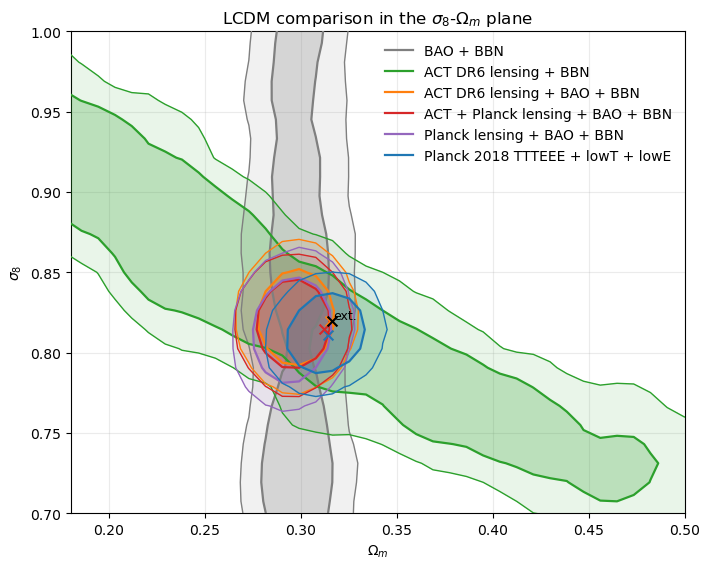

In [5]:
def density_levels_from_hist(hist, credible_levels=(0.68, 0.95)):
    flat = hist.ravel()
    flat = flat[np.isfinite(flat)]
    if flat.size == 0 or np.all(flat <= 0.0):
        return []
    order = np.argsort(flat)[::-1]
    sorted_hist = flat[order]
    cdf = np.cumsum(sorted_hist)
    cdf /= cdf[-1]
    levels = []
    for cl in credible_levels:
        idx = np.searchsorted(cdf, cl, side='left')
        idx = min(idx, sorted_hist.size - 1)
        levels.append(sorted_hist[idx])
    return sorted(set(levels))


def plot_smoothed_contours(
    ax,
    x_samples,
    y_samples,
    color,
    *,
    bins=80,
    label=None,
    x_range=None,
    y_range=None,
    smoothing_sigma=1.1,
    fill_alphas=(0.10, 0.24),
    lw=(1.0, 1.6),
    zorder=3,
):
    hist, xedges, yedges = np.histogram2d(
        np.asarray(x_samples),
        np.asarray(y_samples),
        bins=bins,
        range=[x_range, y_range],
    )
    hist = gaussian_filter(hist, sigma=smoothing_sigma)
    levels = density_levels_from_hist(hist)
    if levels:
        xcenters = 0.5 * (xedges[:-1] + xedges[1:])
        ycenters = 0.5 * (yedges[:-1] + yedges[1:])
        ax.contourf(xcenters, ycenters, hist.T, levels=[levels[0], hist.max()], colors=[color], alpha=fill_alphas[0], zorder=zorder)
        ax.contourf(xcenters, ycenters, hist.T, levels=[levels[-1], hist.max()], colors=[color], alpha=fill_alphas[1], zorder=zorder + 0.1)
        ax.contour(xcenters, ycenters, hist.T, levels=levels, colors=[color], linewidths=lw[:len(levels)], zorder=zorder + 0.2)
    if label is not None:
        ax.plot([], [], color=color, lw=lw[-1], label=label)


plot_order = [selector_to_label(selector) for selector in SELECTORS_TO_LOAD if selector in artifacts]
if not plot_order:
    raise RuntimeError('No saved artifacts were found. Run the driver notebook first.')

xmin = min(float(derived_results[label]['Omega_m'].quantile(0.01)) for label in plot_order)
xmax = max(float(derived_results[label]['Omega_m'].quantile(0.99)) for label in plot_order)
ymin = min(float(derived_results[label]['sigma8'].quantile(0.01)) for label in plot_order)
ymax = max(float(derived_results[label]['sigma8'].quantile(0.99)) for label in plot_order)
xpad = 0.06 * (xmax - xmin)
ypad = 0.06 * (ymax - ymin)
x_range = (xmin - xpad, xmax + xpad)
y_range = (ymin - ypad, ymax + ypad)

fig, ax = plt.subplots(figsize=(7.2, 5.8))
for label in plot_order:
    df = derived_results[label]
    plot_smoothed_contours(
        ax,
        df['Omega_m'],
        df['sigma8'],
        COMBINATION_COLORS[label],
        label=label,
        x_range=x_range,
        y_range=y_range,
    )

for label, values in PAPER_REFERENCE_POINTS.items():
    marker_color = values.get('color', COMBINATION_COLORS.get(label, 'black'))
    ax.scatter(values['Omega_m'], values['sigma8'], marker='x', color=marker_color, s=50, linewidths=1.5, zorder=6)
    if 'extended' in label:
        ax.text(values['Omega_m'] + 0.0008, values['sigma8'] + 0.0008, 'ext.', color=marker_color, fontsize=9, zorder=6)

ax.set_xlabel(r'$\Omega_m$')
ax.set_ylabel(r'$\sigma_8$')
ax.set_title(r'LCDM comparison in the $\sigma_8$-$\Omega_m$ plane')
ax.set_xlim(0.18,0.5)
ax.set_ylim(0.7,1.0)
ax.grid(alpha=0.25)
ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()
